<a href="https://colab.research.google.com/github/fbsilvaRP/OpenCV-Fundamentos/blob/main/SaltNPepper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importando a imagem da web para a edição - Explicando a função `__importaImagem__()`**:


---


Etapas da extração/aquisição da imagem:


1.   **Requisição:** O script envia uma solicitação ao servidor da página.

2.   **Processamento:** O servidor recebe, verifica se o endereço está certo e se ela está funcionando.

3. **Resposta:** A resposta obtida será um pacote de dados. O código 200 será recebido caso a requisição seja bem sucedida.

Alguns comandos utilizados:



*   `resposta.read()`: Lê os dados brutos da página web obtida
*   `bytearray()`: Transforma os dados numa sequeência de bytes
*   `np.asarray(, dtype = "uint8")`: Converte os bytes em um array utilizando a biblioteca Numpy
*   `cv2.imdecode()`: Transforma o array de números em um formato de imagem









In [4]:
from urllib.request import urlopen
import cv2
import matplotlib.pyplot as plt
import numpy as np

#O parâmetro readFlag define como a imagem será lida, sendo o padrão colorida
  #Escrever readFlag = 1 é o equivalente a escrever readFlag = cv2.IMREAD_COLOR

def __importaImagem__(url, readFlag = 1):
  #Realiza uma requisição - a variável "resposta" recebe um pacote de informações da página web
  resposta = urlopen(url)
  #Verifica se a conexão foi bem sucedida - Código 200 no pacote: Requisição aceita
  if resposta.getcode() == 200:
    #O tipo uint8 utiliza valores de intensidade de 0 a 255
    imagem = np.asarray(bytearray(resposta.read()), dtype = "uint8")
    #Transforma as informações para um formato de imagem (arranjo matricial de pixels)
    imagem = cv2.imdecode(imagem, readFlag)
    #Transforma a imagem de BGR para RGB:
    imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
    return imagem
  else:
    print("Erro...")


**Oberservação sobre a imagem obtida...**


---


Por padrão, a biblioteca OpenCV lê as imagens no formato **BGR**(Blue, Green, Red). Para utilizar o matplotlib para exibir a imagem, o formato deve ser convertido para **RGB** utilizando o comando abaixo:

`imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)`

Dimensões (X,Y,Z) da imagem: (493, 1024, 3)
Número de linhas:493
Número de colunas:1024
Quantidade de canais de cores: 3
Imagem original: 


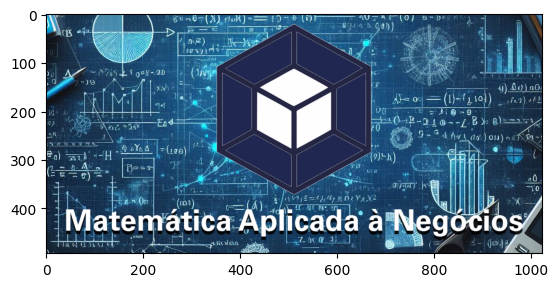

In [26]:
#Importa a imagem utilizando a função acima
foto = __importaImagem__("https://dcm.ffclrp.usp.br/images/mat.png")

#É possível exibir as três
print(f"Dimensões (X,Y,Z) da imagem: {foto.shape}")

print(f"Número de linhas:{foto.shape[0]}")
print(f"Número de colunas:{foto.shape[1]}")
print(f"Quantidade de canais de cores: {foto.shape[2]}")

print("Imagem original: ")
plt.imshow(foto)
plt.show()

Sobre o comando `foto.shape`:


---


Descreve a estrutura do arranjo matricial que compõe o arquivo, fornecendo as dimensões em uma ordem específica:


1.   **Primeiro valor:** Altura (Rows)
2.   **Segundo valor:** Largura (Columns)
3.   **Teceiro valor:** Canais de Cor (Channels)

O terceiro valor indica quantidade de camadas de cores. Exemplos:

*  `(493, 1024, 3)`: Altura largura e 3 camadas de cores (Imagem colorida)
*  `(493, 1024)`: Apenas altura e largura (sem profundidade de cor) - Tons de cinza

**Sobre a biblioteca `urllib.request`:**


---

1.   `urllib.request`: Módulo responsável por lidar com a abertura de URLs;

2.   `.urlopen("endereço web")`: A função realiza uma requisição GET para o servidor web no endereço;



**Adicionando sal e pimenta...**

In [35]:
import random
import cv2
def __addTempero__(img):

  #Recebe o número de linhas (posição zero da lista)
  linha = img.shape[0]
  #Recebe o número de colunas(posição 1 da coluna)
  coluna = img.shape[1]
  #-----------------------------------------------
  #Vefificando se a foto é colorida
  #Caso haja um terceiro valor e ele seja 3, recebe True
  ehColorida = len(img.shape) == 3
  #-----------------------------------------------
  #Produzindo o ruído branco:
  numeroPixels = random.randint(0, 10000)
  for i in range(numeroPixels):
    y = random.randint(0, linha - 1)
    x = random.randint(0, coluna - 1)

    #Se a imagem for colorida(Verdade)
    if ehColorida:
      img[y][x] = [255, 255, 255]
    else:
      img[y][x] = 255
  #-----------------------------------------------
  #Produzindo o ruído preto:
  numeroPixels = random.randint(0, 10000)
  for i in range(numeroPixels):
    y = random.randint(0, linha - 1)
    x = random.randint(0, coluna - 1)

    if ehColorida:
      img[y][x] = [0, 0, 0]
    else:
      img[y][x] = 0

  return img


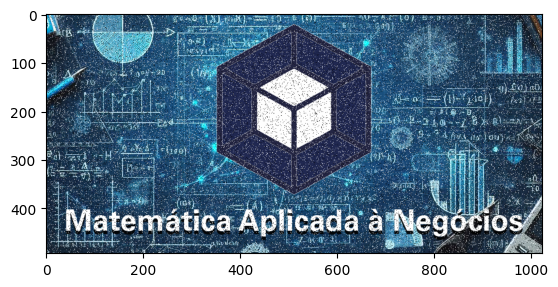

In [37]:
cv2.imwrite("Salt-and-pepper.jpg", __addTempero__(foto))

plt.imshow(foto)
plt.show()